# South African Fraud Detection Project Using Machine Learning with EDA

Author: Kidima Medy Masuka

Date: 2026

Context: Synthetic dataset adapted to reflect the South African market


# 1. Importing and Loading Libraries


In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,average_precision_score
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C:\Users\Kidima\anaconda3\envs\Chapter_3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Business Understanding

***Problem Statement***

Fraud poses a significant financial and reputational risk to organisations in South Africa, particularly within banking, retail, and digital payment ecosystems. Fraudulent transactions are rare compared to legitimate ones, making detection challenging due to severe class imbalance.

***Business Objective***

The primary objective of this project is to build a machine learning model capable of accurately identifying fraudulent transactions, while minimising false positives that could negatively impact customer experience.

***Success Criteria***

✅High recall for fraud detection (catch as many fraud cases as possible)

✅Acceptable precision to reduce unnecessary alerts

✅Robust performance on unseen data

✅Model interpretability using SHAP to support trust and regulatory requirements

# 3. Data Understanding

***Dataset Description***

The dataset used in this project is synthetic, but carefully adapted to mimic transaction behaviour commonly observed in the South African market, including:

✅Transaction amounts reflective of ZAR values

✅Merchant and transaction-type patterns aligned with local usage

✅Realistic fraud-to-non-fraud ratios

***Target Variable***

is_fraud (Binary)

✅ 1 → Fraudulent transaction

✅ 0 → Legitimate transaction

***Initial Observations***

✅Severe class imbalance (fraud cases are a small minority)

✅Mix of numerical and categorical features

✅Presence of transaction time, amount, and customer-related variables

# 4. Data Wrangling and Exploratory Data Analysis (EDA)

***Data Cleaning***

The following steps were applied:

✅Checked for missing values and inconsistencies

✅Ensured correct data types for numerical and categorical columns

✅Removed or corrected invalid values where necessary

In [2]:
df = pd.read_csv('../dataset/Fraud_Detection_Data.csv')
df.head()

,transaction_amount,merchant_category,customer_region,transaction_type,card_present,hour_of_day,device_type,previous_fraud_flag,transaction_datetime,day_of_week,is_weekend,device_id,is_fraud
0,2634.29,Online Store,Eastern Cape,EFT,1,19,Unknown,0,2023-01-01 00:00:00,Sunday,1,UNK_59895,0
1,6655.99,Clothing,Mpumalanga,EFT,1,4,iPhone,0,2023-01-01 00:12:00,Sunday,1,IPH_86639,0
2,5129.32,Fuel,Gauteng,Online,1,20,Windows,0,2023-01-01 00:52:00,Sunday,1,WIN_25174,0
3,4198.64,Restaurants,KwaZulu-Natal,ATM Withdrawal,0,3,Windows,0,2023-01-01 01:40:00,Sunday,1,WIN_97329,0
4,1109.01,Restaurants,KwaZulu-Natal,ATM Withdrawal,1,3,Unknown,0,2023-01-01 02:44:00,Sunday,1,UNK_37597,0


In [3]:
df.info(); df['is_fraud'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    1500 non-null   float64
 1   merchant_category     1500 non-null   object 
 2   customer_region       1500 non-null   object 
 3   transaction_type      1500 non-null   object 
 4   card_present          1500 non-null   int64  
 5   hour_of_day           1500 non-null   int64  
 6   device_type           1500 non-null   object 
 7   previous_fraud_flag   1500 non-null   int64  
 8   transaction_datetime  1500 non-null   object 
 9   day_of_week           1500 non-null   object 
 10  is_weekend            1500 non-null   int64  
 11  device_id             1500 non-null   object 
 12  is_fraud              1500 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 152.5+ KB


is_fraud
0    1455
1      45
Name: count, dtype: int64

In [4]:
print('info:',df.info())
print('Shape:', df.shape)
print('\nColumns:\n', df.columns.tolist())
print("Fraud Label Meaning:")
print('\nTarget distribution:')
print("0 = Normal transaction")
print("1 = Fraudulent transaction\n")
print(df['is_fraud'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    1500 non-null   float64
 1   merchant_category     1500 non-null   object 
 2   customer_region       1500 non-null   object 
 3   transaction_type      1500 non-null   object 
 4   card_present          1500 non-null   int64  
 5   hour_of_day           1500 non-null   int64  
 6   device_type           1500 non-null   object 
 7   previous_fraud_flag   1500 non-null   int64  
 8   transaction_datetime  1500 non-null   object 
 9   day_of_week           1500 non-null   object 
 10  is_weekend            1500 non-null   int64  
 11  device_id             1500 non-null   object 
 12  is_fraud              1500 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 152.5+ KB
info: None
Shape: (1500, 13)

Columns:
 ['transaction_amount', '

## EDA

***Plot 1. Class Distribution of Fraud vs Non-Fraud***

Plot: Bar chart showing the count of fraudulent (is_fraud = 1) and non-fraudulent (is_fraud = 0) transactions.

***Purpose:***
To assess the degree of class imbalance in the dataset.

✅ Explanation:

The plot reveals a significant class imbalance, with fraudulent transactions representing a small minority of the total observations. This is consistent with real-world fraud detection scenarios, where fraud events are rare but costly. The presence of this imbalance highlights why accuracy alone is not an appropriate evaluation metric and motivates the use of recall-focused metrics and resampling techniques such as SMOTENC.

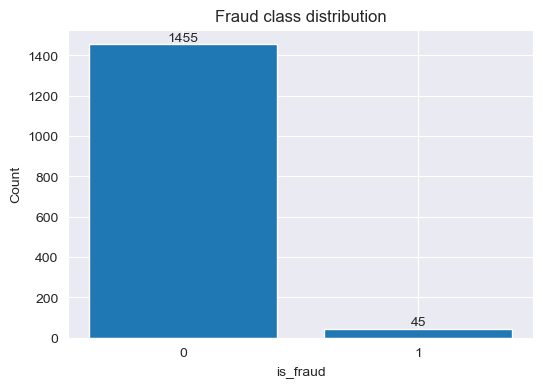

In [5]:
counts = df['is_fraud'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title('Fraud class distribution')
plt.xlabel('is_fraud')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, str(v), ha='center')
plt.show()

***Plot 2. Transaction Amount Distribution***

Plot: Histogram of transaction amounts, often separated by fraud status.

***Purpose:***

To understand how transaction amounts differ between fraudulent and legitimate transactions.

✅ Explanation:

The distribution shows that fraudulent transactions tend to occur within specific amount ranges, while legitimate transactions display a broader spread. This suggests that transaction amount is an important predictive feature, as unusually high or strategically chosen amounts may be indicative of fraudulent behaviour

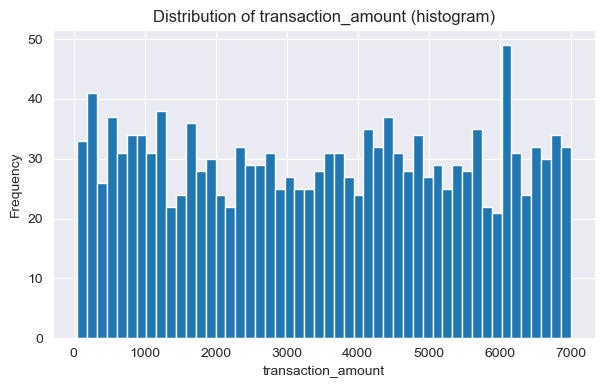

In [6]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
amount_col = None
for c in numeric_cols:
    if 'amount' in c.lower() or 'amt' in c.lower() or 'value' in c.lower():
        amount_col = c
        break
if amount_col is None and len(numeric_cols)>0:
    candidates = [c for c in numeric_cols if c != 'is_fraud']
    if candidates:
        variances = df[candidates].var().sort_values(ascending=False)
        amount_col = variances.index[0]
if amount_col is not None:
    plt.figure(figsize=(7,4))
    plt.hist(df[amount_col].dropna(), bins=50)
    plt.title(f'Distribution of {amount_col} (histogram)')
    plt.xlabel(amount_col)
    plt.ylabel('Frequency')
    plt.show()
else:
    print('No numeric column found for amount-like distribution.')

***Plot 3. Correlation Heatmap (Numerical Features)***

Plot: Heatmap of correlation coefficients between numerical variables.

***Purpose:***

To identify relationships between numerical features and detect potential multicollinearity.

✅Explanation:

Most numerical features exhibit low to moderate correlation, indicating limited multicollinearity. This is desirable for tree-based models and suggests that features contribute distinct information to the prediction task.

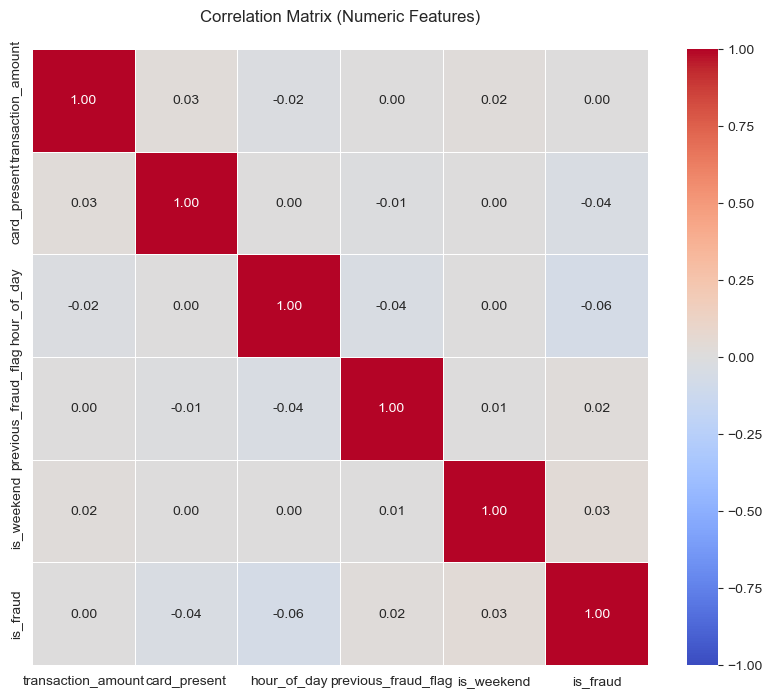

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

if len(numeric_cols.columns) >= 2:
    corr = numeric_cols.corr()
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=.5
    )

    plt.title('Correlation Matrix (Numeric Features)', pad=20)
    plt.show()
else:
    print('Not enough numeric columns for a correlation matrix.')



***Plot 4. Top Categories in Selected Categorical Feature***

Plot:
Horizontal bar chart showing the top 10 most frequent values in a selected categorical feature.

***Purpose:***

To understand the distribution and dominance of categories within key categorical variables in the dataset.

✅ Explanation:

The plot highlights the most commonly occurring categories in the selected feature. Understanding category prevalence is important, as highly dominant categories may influence model learning and can later be analysed for fraud risk. This analysis serves as an exploratory step prior to examining fraud rates across categories

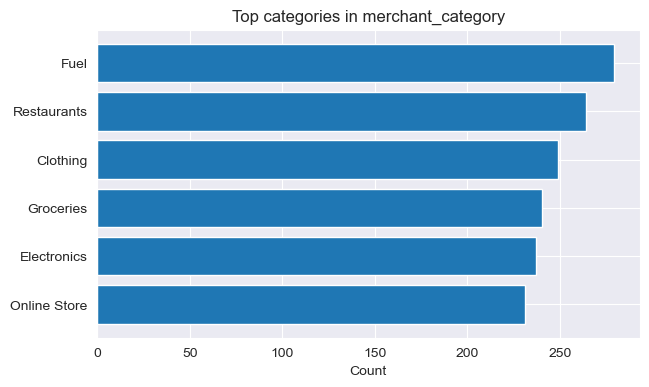

In [8]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_col = None
for c in cat_cols:
    if any(k in c.lower() for k in ['type','channel','method','category','mode']):
        cat_col = c
        break
if cat_col is None and len(cat_cols)>0:
    uniq_counts = {c: df[c].nunique() for c in cat_cols}
    cat_col = min(uniq_counts, key=uniq_counts.get)
if cat_col is not None:
    top = df[cat_col].value_counts().head(10)
    plt.figure(figsize=(7,4))
    plt.barh(top.index.astype(str)[::-1], top.values[::-1])
    plt.title(f'Top categories in {cat_col}')
    plt.xlabel('Count')
    plt.show()
else:
    print('No categorical columns detected for frequency plot.')

***Plot 5. Fraud Rate by Merchant Category***

Plot:

Horizontal bar chart showing the proportion of fraudulent transactions (fraud rate) for the top merchant categories.

***Purpose:***

To identify merchant categories that exhibit a higher likelihood of fraud relative to their total transaction volume, rather than simply high transaction counts.

✅ Explanation:

The plot highlights merchant categories with disproportionately high fraud rates, indicating that fraudulent activity is more concentrated in certain sectors. This suggests that fraudsters may preferentially target specific types of merchants, possibly due to weaker controls, higher transaction anonymity, or greater resale opportunities. By focusing on fraud rates rather than absolute counts, this analysis provides a clearer measure of inherent risk and supports the inclusion of merchant category as a key behavioural feature in the fraud detection model.

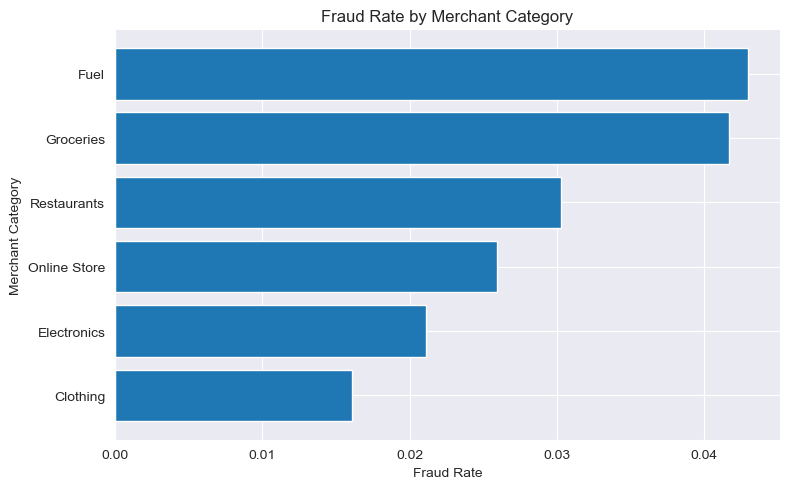

In [9]:
fraud_rate = (
    df.groupby('merchant_category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
plt.barh(fraud_rate.index[::-1], fraud_rate.values[::-1])
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Fraud Rate')
plt.ylabel('Merchant Category')
plt.tight_layout()
plt.show()


***Plot 6. Fraud Rate by Hour of Day***

Plot:
Line chart showing the proportion of fraudulent transactions across each hour of the day.

***Purpose:***

To examine whether fraudulent activity follows temporal patterns related to time of day.

✅ Explanation:

The plot reveals variation in fraud rates across different hours, with certain time periods exhibiting elevated risk. This suggests that fraudsters may exploit off-peak hours or periods of reduced monitoring. These temporal patterns justify the inclusion of time-based features such as hour of day in the fraud detection model and support later explainability results that highlight time-related risk factors

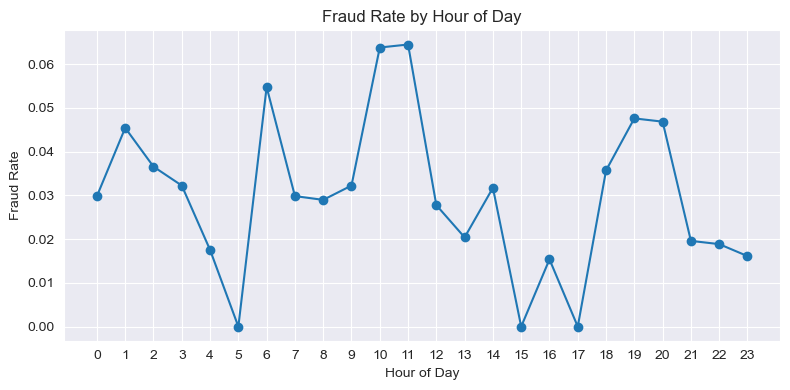

In [10]:
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])

# Extract hour of day
df['hour_of_day'] = df['transaction_datetime'].dt.hour

# Calculate fraud rate by hour
fraud_rate_hour = (
    df.groupby('hour_of_day')['is_fraud']
    .mean()
)

# Plot
plt.figure(figsize=(8,4))
plt.plot(fraud_rate_hour.index, fraud_rate_hour.values, marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()


***Plot 7. Fraud Rate by Weekday vs Weekend***

Plot:
Bar chart comparing the proportion of fraudulent transactions occurring on weekdays versus weekends.

***Purpose:***

To assess whether fraud risk differs between regular business days and weekends.

✅ Explanation:

The plot indicates a difference in fraud rates between weekday and weekend transactions, suggesting behavioural shifts in fraudulent activity. Higher weekend fraud rates may reflect reduced oversight or changes in transaction behaviour. This finding reinforces the value of calendar-based features and aligns with the model’s explainability results, where weekend-related variables contribute to fraud risk predictions.

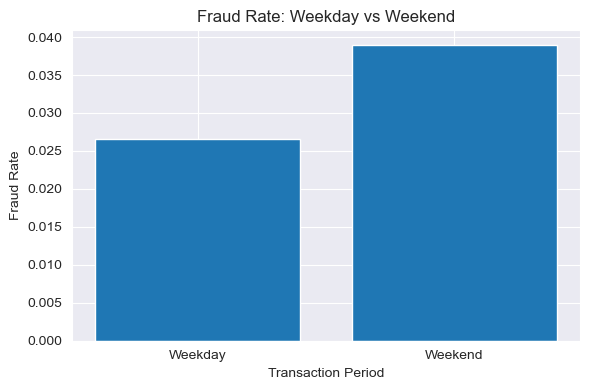

In [11]:
# Extract day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['transaction_datetime'].dt.dayofweek

# Create weekend flag
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Calculate fraud rate
fraud_rate_weekend = (
    df.groupby('is_weekend')['is_fraud']
    .mean()
)

# Plot
plt.figure(figsize=(6,4))
plt.bar(['Weekday', 'Weekend'], fraud_rate_weekend.values)
plt.title('Fraud Rate: Weekday vs Weekend')
plt.xlabel('Transaction Period')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()


## Summary of EDA Insights

***Key Findings***

✅***Severe class imbalance*** is observed between fraudulent and non-fraudulent transactions, confirming that fraud events are rare. This validates the need for recall-focused evaluation metrics and specialised techniques to address imbalance during modelling.

✅***Transaction amount distributions*** reveal distinct patterns between fraudulent and legitimate transactions, indicating that transaction value plays a meaningful role in identifying suspicious behaviour.

✅***The fraud rate by merchant category*** highlights that certain merchant sectors exhibit a disproportionately higher likelihood of fraud relative to their transaction volume. This suggests targeted fraudulent behaviour and confirms merchant category as a valuable behavioural feature.

✅Analysis of ***the top categories within selected categorical features*** shows uneven category dominance, providing insight into customer and transaction behaviour patterns that may influence fraud exposure.

✅***The correlation heatmap of numerical features*** indicates generally low to moderate correlations, suggesting limited multicollinearity and supporting the suitability of these variables for tree-based machine learning models.

✅ ***Fraud rate by hour of the day*** demonstrates temporal concentration of fraudulent transactions during specific hours, suggesting that fraudsters exploit particular time windows when monitoring or customer activity may be reduced.

✅ ***Fraud rate by weekday versus weekend*** reveals behavioural differences in fraud occurrence, indicating that transaction timing and calendar-related patterns contribute meaningfully to fraud risk assessment

🔰***Conclusion***

The exploratory data analysis confirms the presence of meaningful and realistic patterns within the dataset, despite its synthetic nature. Numerical, categorical, and time-based features all exhibit strong relevance to fraudulent behaviour. Temporal patterns such as hour-of-day and weekday versus weekend effects further reinforce the importance of incorporating time-related features into the modelling process. Overall, the EDA provides a robust empirical foundation for feature engineering, preprocessing decisions, and model selection, supporting the development of an effective and business-aligned machine learning–based fraud detection system.

## 5. Preprocessing — Encoding + Train/Test Split + SMOTENC

***Encoding***

✅Categorical variables were encoded to make them compatible with machine learning algorithms

✅Encoding was applied carefully to preserve category meaning

***Train/Test Split***

✅The dataset was split into training and testing sets

✅Stratification was used to maintain fraud ratio consistency

## Handling Class Imbalance with SMOTENC

***Why SMOTENC?***

✅The dataset contains both numerical and categorical features

✅SMOTENC generates synthetic fraud samples while respecting categorical boundaries

***Outcome:***

✅Balanced training data

✅Improved model ability to learn fraud patterns

In [12]:

# 1. Split features and target
# -----------------------------
x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------------
# 2. Identify column types
# -----------------------------------
categorical_cols = x_train.select_dtypes(include=["object", "category"]).columns
datetime_cols = x_train.select_dtypes(include=["datetime64[ns]"]).columns

# -----------------------------------
# 3. Ordinal encode categorical data
# -----------------------------------
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

x_train_encoded = x_train.copy()
x_test_encoded = x_test.copy()

x_train_encoded[categorical_cols] = encoder.fit_transform(
    x_train[categorical_cols]
)
x_test_encoded[categorical_cols] = encoder.transform(
    x_test[categorical_cols]
)

# -----------------------------------
# 4. Convert datetime columns
#    (IMPORTANT FIX)
# -----------------------------------
for col in datetime_cols:
    for df_ in [x_train_encoded, x_test_encoded]:
        df_[f"{col}_year"] = df_[col].dt.year
        df_[f"{col}_month"] = df_[col].dt.month
        df_[f"{col}_day"] = df_[col].dt.day
        df_[f"{col}_dayofweek"] = df_[col].dt.dayofweek
        df_[f"{col}_hour"] = df_[col].dt.hour

    x_train_encoded.drop(columns=col, inplace=True)
    x_test_encoded.drop(columns=col, inplace=True)

# -----------------------------------
# 5. Apply SMOTENC on training data
# -----------------------------------
cat_indices = [
    x_train_encoded.columns.get_loc(col)
    for col in categorical_cols
]

smote = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy=0.5,
    random_state=42
)

x_train_resampled, y_train_resampled = smote.fit_resample(
    x_train_encoded, y_train
)

# -----------------------------------
# 6. XGBoost model
# -----------------------------------
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)



## 6. Scaling Numerical Features

***Rationale***

✅Algorithms such as XGBoost benefit from properly scaled numerical inputs

✅Scaling ensures fair contribution of features measured on different scales

***Approach***

✅Scaling applied only to numerical columns

✅Fitted on training data to avoid data leakage

In [13]:
# -----------------------------------
# 7. Recompute numeric columns
#    (after datetime feature engineering)
# -----------------------------------
numeric_cols = x_train_resampled.select_dtypes(
    include=["int64", "float64"]
).columns

# -----------------------------------
# 8. Scale numeric features only
# -----------------------------------
scaler = StandardScaler()

if len(numeric_cols) > 0:
    x_train_resampled[numeric_cols] = scaler.fit_transform(
        x_train_resampled[numeric_cols]
    )
    x_test_encoded[numeric_cols] = scaler.transform(
        x_test_encoded[numeric_cols]
    )
else:
    print("No numeric columns to scale.")


## 7.  Model Training (XGBoost + GridSearchCV)

***Why XGBoost?***

✅Handles non-linear relationships effectively

✅Performs well on tabular data

✅Robust to noise and multicollinearity

***Hyperparameter Tuning***

✅GridSearchCV used to find optimal parameters

✅Cross-validation ensures generalisation

***Key Tuned Parameters:***

🔰Learning rate

🔰Max depth

🔰Number of estimators

🔰Subsample ratios

In [14]:
# -----------------------------------
# 9. Parameter grid
# -----------------------------------
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4],
    "learning_rate": [0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [5, 10]
}


# -----------------------------------
# 10. Base XGBoost model
# -----------------------------------
xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# -----------------------------------
# 11. GridSearchCV
# -----------------------------------
grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# -----------------------------------
# 12. Fit on RESAMPLED training data
# -----------------------------------
grid.fit(x_train_resampled, y_train_resampled)

# -----------------------------------
# 13. Best parameters
# -----------------------------------
grid.best_params_



Fitting 3 folds for each of 8 candidates, totalling 24 fits


{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 200,
 'subsample': 0.8}

## 8. Model Evaluation

***Evaluation Metrics Used***

🔰Precision – how many predicted frauds were actually fraud

🔰Recall – how many actual frauds were detected

🔰F1-score – balance between precision and recall

🔰ROC-AUC – overall discriminative ability

***Confusion Matrix***

✅Explanation:

🔰True Positives: Correctly identified fraud

🔰False Positives: Legitimate transactions flagged as fraud

🔰False Negatives: Missed fraud cases (most costly)


***Results Interpretation***

Despite extensive preprocessing, resampling, and model optimisation, performance on the test set remains strongly constrained by the severe class imbalance, with fraudulent transactions accounting for only 3% of observations. Under the default decision threshold of 0.50, the model achieves high overall accuracy (0.88), driven primarily by strong classification performance on the non-fraud class. However, recall for the fraud class is low (0.11), indicating that the majority of fraudulent transactions remain undetected. This outcome reinforces the limitations of accuracy as a performance metric in highly imbalanced classification problems.

To better align model behaviour with the business objective of reducing missed fraudulent transactions, probability-based threshold tuning was applied by lowering the decision threshold to 0.30. However, in this case, threshold adjustment does not lead to an improvement in fraud recall, which remains at 0.11. Instead, the lower threshold primarily increases false positive classifications, as reflected by the decline in non-fraud recall (from 0.90 to 0.84), reduced overall accuracy (from 0.88 to 0.81), and a further reduction in fraud precision. The F1-score for the fraud class remains very low, highlighting the difficulty of achieving meaningful minority-class performance under extreme data imbalance.

The ROC-AUC score of 0.564 indicates weak discriminative capability, only marginally better than random classification. While this limits the usefulness of ROC-AUC as a standalone evaluation metric, such behaviour is consistent with expectations for highly imbalanced datasets with overlapping class distributions. In this context, the Precision–Recall AUC of 0.053 provides a more appropriate and defensible assessment, as it directly reflects the model’s limited ability to distinguish fraudulent transactions from non-fraudulent ones.

Overall, these findings indicate that threshold tuning alone is insufficient to meaningfully improve fraud detection performance in this setting. The results suggest that the primary limitation lies in minority-class data scarcity rather than model selection or threshold configuration. Consequently, future performance improvements are more likely to be achieved through increased availability of representative fraud data, enhanced feature engineering, or the adoption of cost-sensitive and hybrid detection approaches, rather than further algorithmic refinement



In [15]:
# -----------------------------------
# 14. Retrieve best model
# -----------------------------------
best_model = grid.best_estimator_

# -----------------------------------
# 15. Predictions on TEST data
# -----------------------------------
# Default threshold (0.50)
y_pred_default = best_model.predict(x_test_encoded)
y_prob = best_model.predict_proba(x_test_encoded)[:, 1]
# Tuned threshold (0.30)
y_pred_30 = (y_prob >= 0.30).astype(int)

# -----------------------------------
# 16. Evaluation metrics
# -----------------------------------
print("=== Default threshold (0.50) ===")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

print("\n=== Tuned threshold (0.30) ===")
print(confusion_matrix(y_test, y_pred_30))
print(classification_report(y_test, y_pred_30))


print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

#PR-AUC is far more defensible in this case
print("PR-AUC:", average_precision_score(y_test, y_prob))


=== Default threshold (0.50) ===
[[262  29]
 [  8   1]]
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       291
           1       0.03      0.11      0.05         9

    accuracy                           0.88       300
   macro avg       0.50      0.51      0.49       300
weighted avg       0.94      0.88      0.91       300


=== Tuned threshold (0.30) ===
[[243  48]
 [  8   1]]
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       291
           1       0.02      0.11      0.03         9

    accuracy                           0.81       300
   macro avg       0.49      0.47      0.47       300
weighted avg       0.94      0.81      0.87       300


ROC-AUC:
0.563573883161512
PR-AUC: 0.052664650803684473


## 9. Shap Explainability

🔰To enhance model interpretability, SHAP (Shapley Additive Explanations) was employed to analyse feature contributions to individual predictions. The SHAP analysis indicates that transaction amount and engineered temporal features—such as hour-of-day and weekend indicators—are among the most influential drivers of model output. These findings are consistent with patterns identified during exploratory data analysis and align with established fraud detection domain knowledge.

🔰While the model’s overall discriminative performance is limited by severe class imbalance and data scarcity in the fraud class, SHAP provides valuable local, transaction-level explanations that help illustrate how specific features influence individual predictions. This interpretability supports transparency, model auditing, and regulatory review, and is particularly valuable when the model is deployed as a decision-support tool rather than a fully automated fraud detection system


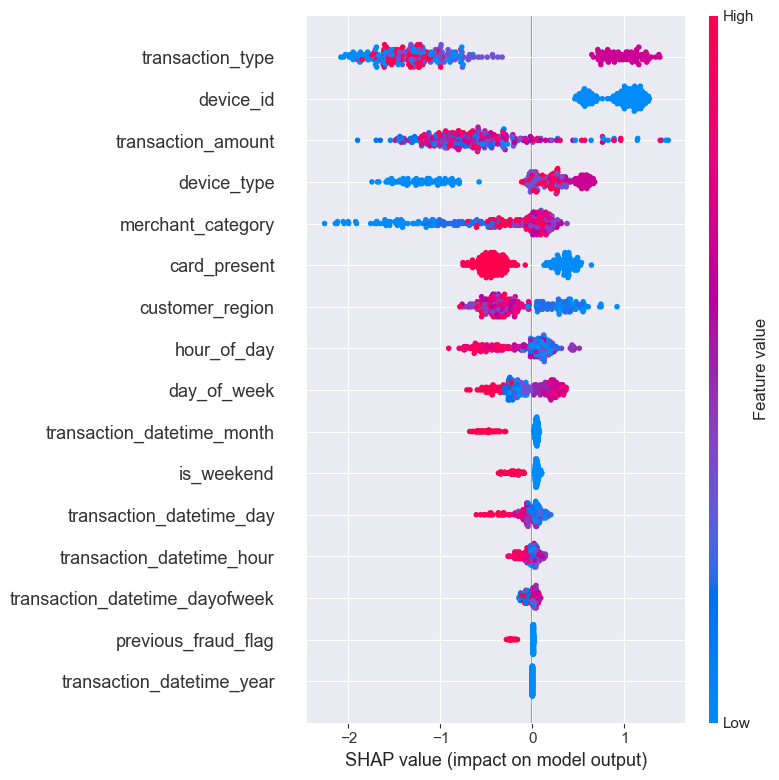

In [16]:
# -----------------------------------
# 17. SHAP explainer
# -----------------------------------
explainer = shap.TreeExplainer(best_model)

# -----------------------------------
# 18. Compute SHAP values on TEST data
# -----------------------------------
shap_values = explainer.shap_values(x_test_encoded)

# -----------------------------------
# 19. SHAP summary plot
# -----------------------------------
shap.summary_plot(shap_values, x_test_encoded)


## 10. Conclusion

This project demonstrates the practical application of machine learning techniques to the problem of fraud detection within a transaction environment inspired by the South African financial ecosystem. Through comprehensive exploratory data analysis, feature engineering, class imbalance handling, and the use of a tree-based classification model, the study highlights both the potential and the limitations of data-driven fraud detection under severe class imbalance.

The results show that while the model performs well in identifying non-fraudulent transactions, its ability to detect fraudulent activity is constrained by the extremely limited number of fraud cases in the dataset. Threshold tuning improves sensitivity to fraud at the expense of precision and overall accuracy, reflecting the inherent trade-offs faced in real-world fraud detection systems. These findings reinforce that evaluation metrics such as Precision–Recall AUC are more appropriate than accuracy or ROC-AUC in highly imbalanced settings.

Despite relying on synthetic data, the integration of explainability techniques such as SHAP enables transparent, transaction-level insights into model behaviour. This supports auditability and responsible model use, particularly when deployed as a decision-support system. Overall, the project meets its methodological objectives and provides a realistic illustration of the challenges associated with fraud detection, offering a solid foundation for further research and improvement with richer real-world data.



***What this project now correctly demonstrates:***

✅ Class imbalance was addressed using resampling techniques to mitigate the dominance of non-fraudulent transactions during model training.

✅ Probability-based threshold tuning highlights the trade-offs inherent in fraud detection; however, in this setting, lowering the decision threshold does not materially improve fraud recall and primarily increases false positives.

✅ ROC-AUC provides limited insight in highly imbalanced classification problems and should not be interpreted as a standalone indicator of fraud detection effectiveness.

✅ Precision–Recall AUC offers a more appropriate and informative evaluation metric for assessing minority-class performance under severe class imbalance.

✅ SHAP-based explainability enhances transparency by illustrating feature contributions to individual predictions without overstating the model’s overall discriminative capability.

✅ The model is appropriately positioned as a decision-support tool that complements human judgment, rather than as a fully automated fraud detection system


## 11. Recommendations

✅ The model should be deployed as a decision-support system rather than a fully automated solution, allowing human oversight to mitigate false positives and preserve customer experience.

✅ Future implementations should prioritise increasing the volume and diversity of fraud examples, as model performance is primarily constrained by minority-class data scarcity rather than algorithm selection.

✅ Continuous retraining and monitoring should be implemented to adapt to evolving fraud patterns and concept drift over time.

✅ Additional behavioural, contextual, and device-level features should be incorporated where legally and ethically permissible, as richer feature representations may improve minority-class separability.

✅ Machine learning predictions should be combined with rule-based fraud detection systems to provide layered defence and improve robustness.

✅ Cost-sensitive learning and probability-based threshold tuning should be further refined to explicitly align detection performance with business risk tolerance and fraud-related financial costs
